## Contents

1. [Spatial Covariance Matrix](#spatial-covariance-matrix)
2. [Sample Covariance Estimation](#sample-covariance-estimation)
3. [Forward–Backward Averaging](#forward-backward-averaging)
4. [Diagonal Loading](#diagonal-loading)
5. [Eigendecomposition](#eigendecomposition)
6. [Estimating the Number of Sources](#estimating-the-number-of-sources)

<a id="spatial-covariance-matrix"></a>

## Spatial Covariance Matrix

The **spatial covariance matrix** is a statistical description of the signals observed across an antenna array. It captures the signal power at each antenna channel together with the amplitude and phase relationships between different channels.

For the array snapshot

$$
\mathbf{x}[l]
=
\mathbf{A}\mathbf{s}[l]
+
\mathbf{n}[l],
$$

the theoretical covariance matrix is defined as

$$
\mathbf{R}_{xx}
=
\mathbb{E}
\left[
\mathbf{x}[l]\mathbf{x}^{H}[l]
\right],
$$

where $(\cdot)^H$ denotes the Hermitian transpose and $\mathbb{E}[\cdot]$ denotes statistical expectation.

The inter-channel phase relationships contained in $\mathbf{R}_{xx}$ depend on the directions of the incident wavefronts. Therefore, the covariance matrix preserves the spatial information required for direction-of-arrival estimation while averaging random variations between individual observations.

The covariance matrix is the main input to covariance-based DoA algorithms:

$$
\text{Array snapshots}
\rightarrow
\mathbf{R}_{xx}
\rightarrow
\text{Bartlett, Capon, MUSIC, or ESPRIT}.
$$

Using multiple snapshots provides a more stable spatial representation than processing a single noisy snapshot. The quality of the covariance estimate directly affects angular resolution, estimation stability, and the ability to separate multiple sources.

<a id="sample-covariance-estimation"></a>

## Sample Covariance Estimation

The theoretical covariance matrix requires an expectation over an unlimited number of observations and cannot be computed directly from measured radar data. In practice, it is approximated using a finite set of $L$ array snapshots:

$$
\hat{\mathbf{R}}_{xx}
=
\frac{1}{L}
\sum_{l=0}^{L-1}
\mathbf{x}[l]\mathbf{x}^{H}[l].
$$

The snapshots can be collected into the snapshot matrix

$$
\mathbf{X}
=
\begin{bmatrix}
\mathbf{x}[0] &
\mathbf{x}[1] &
\cdots &
\mathbf{x}[L-1]
\end{bmatrix}
\in
\mathbb{C}^{M \times L},
$$

where $M$ is the number of physical or virtual antenna channels and $L$ is the number of snapshots.

The sample covariance matrix can then be written in matrix form as

$$
\hat{\mathbf{R}}_{xx}
=
\frac{1}{L}
\mathbf{X}\mathbf{X}^{H}
$$

with $\hat{\mathbf{R}}_{xx} \in \mathbb{C}^{M \times M}.$

Each diagonal element represents the average power observed by one antenna channel:

$$
[\hat{\mathbf{R}}_{xx}]_{m,m}
=
\frac{1}{L}
\sum_{l=0}^{L-1}
|x_m[l]|^2.
$$

Each off-diagonal element describes the complex spatial correlation between two antenna channels:

$$
[\hat{\mathbf{R}}_{xx}]_{m,n}
=
\frac{1}{L}
\sum_{l=0}^{L-1}
x_m[l]x_n^{*}[l].
$$

The magnitude of an off-diagonal element indicates the strength of the correlation, while its phase contains information about the relative spatial phase between the antenna channels.

Simulated covariance matrix for one sources placed on off-boresight:


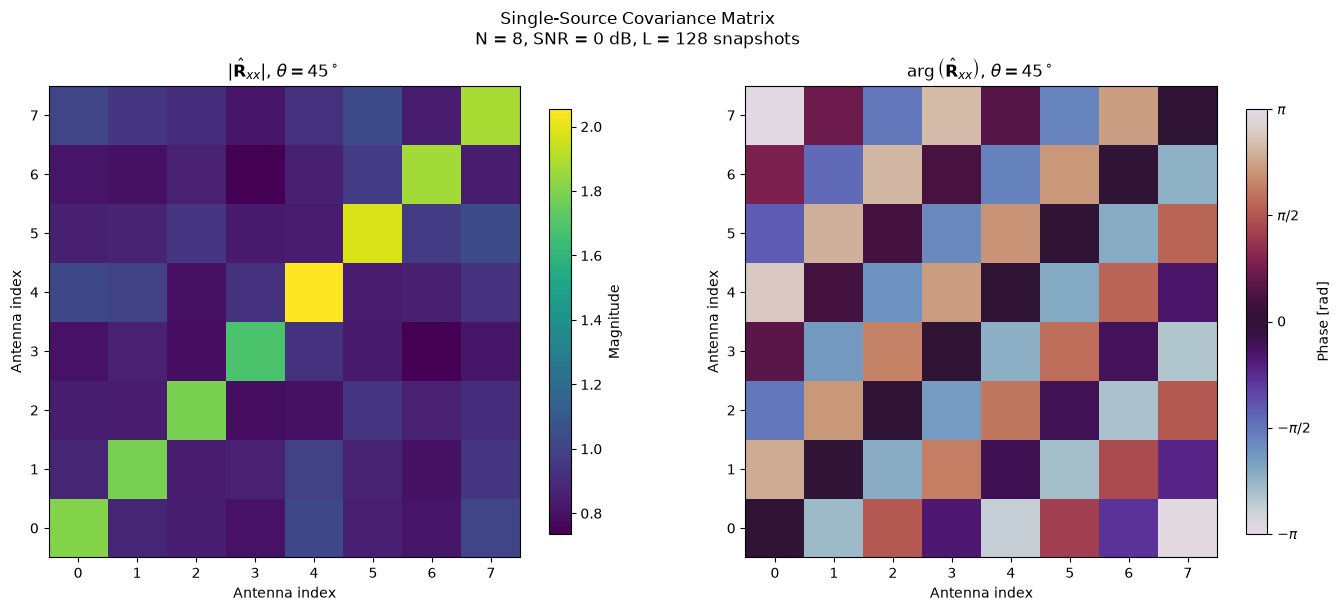

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------
N = 8
L = 128
snr_db = 0
angles_deg = [0, 45]

theta_idx = 1  # 0 -> broadside, 1 -> 45 degrees

rng = np.random.default_rng(0)

sensor_idx = np.arange(N)
noise_power = 10 ** (-snr_db / 10)

covariance_magnitudes = []
covariance_phases = []

for theta_deg in angles_deg:

    # Steering vector of one source
    theta_rad = np.deg2rad(theta_deg)

    a = np.exp(
        1j * np.pi * sensor_idx * np.sin(theta_rad)
    )[:, np.newaxis]

    # L snapshots of one unit-power source
    s = (
        rng.standard_normal((1, L))
        + 1j * rng.standard_normal((1, L))
    ) / np.sqrt(2)

    # Complex white Gaussian noise
    noise = np.sqrt(noise_power / 2) * (
        rng.standard_normal((N, L))
        + 1j * rng.standard_normal((N, L))
    )

    # Received array snapshots
    X = a @ s + noise

    # Sample covariance matrix
    R = X @ X.conj().T / L

    covariance_magnitudes.append(np.abs(R))
    covariance_phases.append(np.angle(R))


# Use the same scale for both images
vmax = max(R_mag.max() for R_mag in covariance_magnitudes)

R_mag = covariance_magnitudes[theta_idx]
R_phase = covariance_phases[theta_idx]
theta_deg = angles_deg[theta_idx]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6),
    constrained_layout=True
)

# Covariance magnitude
image_mag = axes[0].imshow(
    R_mag,
    origin="lower",
    aspect="equal"
)

axes[0].set_title(
    rf"$|\hat{{\mathbf{{R}}}}_{{xx}}|$, "
    rf"$\theta={theta_deg}^\circ$"
)
axes[0].set_xlabel("Antenna index")
axes[0].set_ylabel("Antenna index")

fig.colorbar(
    image_mag,
    ax=axes[0],
    shrink=0.9,
    label="Magnitude"
)

# Covariance phase
image_phase = axes[1].imshow(
    R_phase,
    origin="lower",
    aspect="equal",
    vmin=-np.pi,
    vmax=np.pi,
    cmap="twilight"
)

axes[1].set_title(
    rf"$\arg\left(\hat{{\mathbf{{R}}}}_{{xx}}\right)$, "
    rf"$\theta={theta_deg}^\circ$"
)
axes[1].set_xlabel("Antenna index")
axes[1].set_ylabel("Antenna index")

phase_cbar = fig.colorbar(
    image_phase,
    ax=axes[1],
    shrink=0.9,
    label="Phase [rad]"
)

phase_cbar.set_ticks(
    [-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi]
)
phase_cbar.set_ticklabels(
    [
        r"$-\pi$",
        r"$-\pi/2$",
        r"$0$",
        r"$\pi/2$",
        r"$\pi$"
    ]
)

fig.suptitle(
    f"Single-Source Covariance Matrix\n"
    f"N = {N}, SNR = {snr_db} dB, L = {L} snapshots"
)

plt.show()

Magnitude and phase of the simulated covariance matrix is consistent with the plot for covariance matrix formed in AWR2243 for off-boreside single corner reflector

<p align="center">
  <img
    src="../docs/images/covariance.png"
    alt="covariance matrix"
    width="90%">
</p>

For a single source, the covariance magnitude remains broadly similar across antenna pairs, while the diagonal elements are larger because they also include receiver-noise power. The source direction is primarily encoded in the covariance phase: for the off-boresight target, the phase varies linearly with antenna-index separation and appears as wrapped diagonal bands.

The sample covariance matrix is Hermitian and positive semidefinite:

$$
\hat{\mathbf{R}}_{xx}
=
\hat{\mathbf{R}}_{xx}^{H},
\qquad
\hat{\mathbf{R}}_{xx}
\succeq 0.
$$

Its rank is limited by both the number of antenna channels and the number of available snapshots:

$$
\operatorname{rank}
\left(
\hat{\mathbf{R}}_{xx}
\right)
\leq
\min(M,L).
$$

Consequently, when $L<M$, the sample covariance matrix is rank deficient. This is particularly important for Capon beamforming, which requires a well-conditioned covariance matrix, and for subspace methods, which require reliable separation between the signal and noise subspaces.

<a id="forward-backward-averaging"></a>

## Forward–Backward Averaging

Forward–backward averaging is a covariance preprocessing technique for **centro-symmetric arrays**, such as a uniform linear array. It combines the covariance matrix obtained from the original antenna ordering with the covariance matrix corresponding to the conjugated and reversed array observation.

Let $\hat{\mathbf{R}}_{xx}$ denote the sample covariance matrix of an $M$-element array. The forward–backward averaged covariance matrix is

$$
\hat{\mathbf{R}}_{\mathrm{FB}}
=

\frac{1}{2}
\left(
\hat{\mathbf{R}}*{xx}
+
\mathbf{J}
\hat{\mathbf{R}}*{xx}^{*}
\mathbf{J}
\right)
$$

where $(\cdot)^*$ denotes complex conjugation and $\mathbf{J}$ is the exchange matrix:

$$
\mathbf{J}
=
\begin{bmatrix}
0 & 0 & \cdots & 0 & 1 \\
0 & 0 & \cdots & 1 & 0 \\
\vdots & \vdots & \ddots & \vdots & \vdots \\
0 & 1 & \cdots & 0 & 0 \\
1 & 0 & \cdots & 0 & 0
\end{bmatrix}.
$$

Multiplication by $\mathbf{J}$ reverses the order of the antenna channels. Therefore,

$$
\mathbf{J}
\hat{\mathbf{R}}_{xx}^{*}
\mathbf{J}
$$

represents the covariance matrix associated with the conjugated backward array observation.

For an ideal centro-symmetric array, the theoretical covariance matrix satisfies

$$
\mathbf{R}_{xx}
=

\mathbf{J}
\mathbf{R}_{xx}^{*}
\mathbf{J}.
$$

A covariance matrix estimated from a finite number of noisy snapshots generally does not satisfy this property exactly. Forward–backward averaging enforces conjugate centro-symmetry:

$$
\hat{\mathbf{R}}_{\mathrm{FB}}
=

\mathbf{J}
\hat{\mathbf{R}}_{\mathrm{FB}}^{*}
\mathbf{J}.
$$

By incorporating the known array symmetry, forward–backward averaging reduces finite-sample estimation errors and can improve the stability of the covariance eigenstructure. This is especially useful when only a limited number of snapshots are available.

Forward–backward averaging can provide:

* a covariance estimate consistent with the centro-symmetric array geometry;
* more stable signal and noise subspace estimation;
* improved MUSIC and ESPRIT performance under limited snapshot support;
* the structural property required by real-valued unitary transformations used in Unitary ESPRIT.

Forward–backward averaging does not create independent measurements and does not generally restore the rank lost because of fully coherent sources. Spatial smoothing is normally required for coherent-source decorrelation, although the two techniques are often used together.

The python snippet illustrates how FB averaging makes a covariance estimate consistent with the centro-symmetric array geometry:


Broadside covariance matrix
Nominal source angle  : 0.0 deg
Matrix shape          : (8, 8)

Before FB averaging
-------------------
Hermitian error       : 0.000e+00
Centro-symmetry error : 2.052e-01
Condition number      : 6.998e+04

After FB averaging
------------------
Hermitian error       : 0.000e+00
Centro-symmetry error : 0.000e+00
Condition number      : 4.112e+04

Change introduced by FB averaging
---------------------------------
Relative matrix change: 1.026e-01


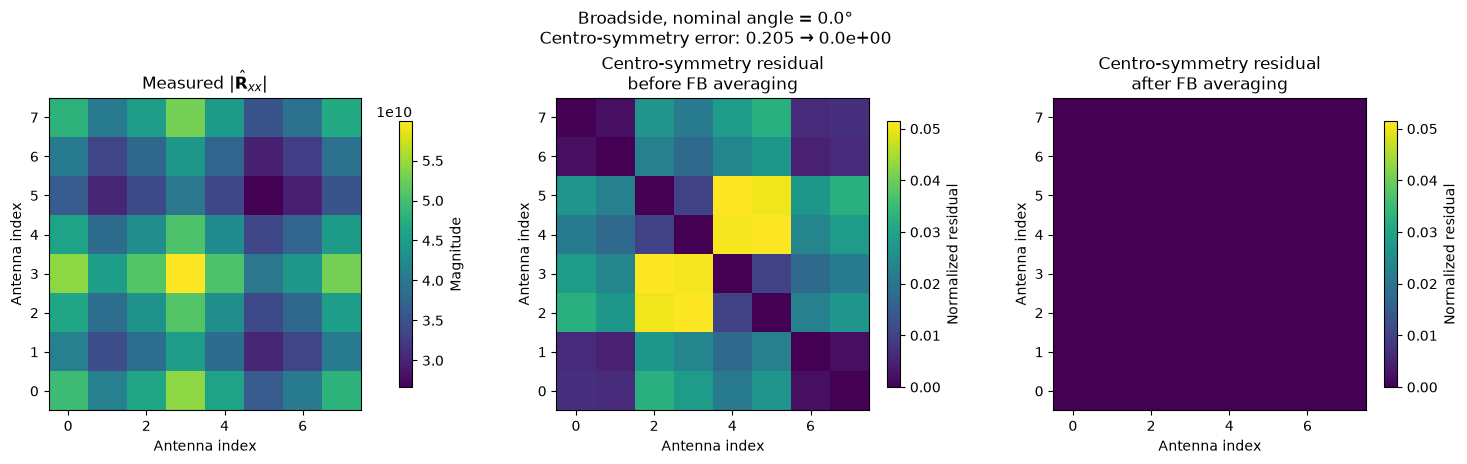


Off-boresight covariance matrix
Nominal source angle  : 45.0 deg
Matrix shape          : (8, 8)

Before FB averaging
-------------------
Hermitian error       : 0.000e+00
Centro-symmetry error : 4.501e-01
Condition number      : 3.358e+04

After FB averaging
------------------
Hermitian error       : 0.000e+00
Centro-symmetry error : 0.000e+00
Condition number      : 1.376e+04

Change introduced by FB averaging
---------------------------------
Relative matrix change: 2.250e-01


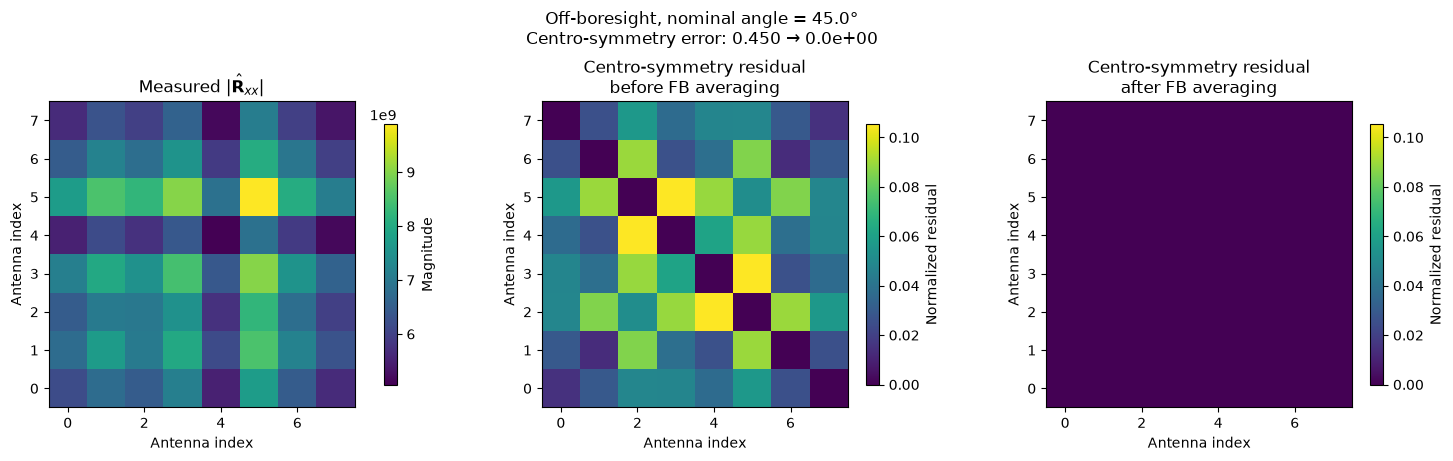

In [4]:
import numpy as np
from pathlib import Path

# ------------------------------------------------------------
# Load measured covariance matrices
# ------------------------------------------------------------

data_dir = Path("..") / "data"

covariance_cases = [
    (
        "Broadside",
        0.0,
        np.load(data_dir / "covariance_matrix_broadside.npy"),
    ),
    (
        "Off-boresight",
        45.0,
        np.load(data_dir / "covariance_matrix_off_boresight.npy"),
    ),
]

import matplotlib.pyplot as plt


def plot_fb_effect(R, R_fb, J, case_name, theta_deg):
    """
    Visualize the conjugate centro-symmetry residual
    before and after forward-backward averaging.
    """

    norm_R = np.linalg.norm(R, ord="fro")

    residual_before = np.abs(R - J @ R.conj() @ J) / norm_R
    residual_after = np.abs(R_fb - J @ R_fb.conj() @ J) / norm_R

    # Same scale for a direct before/after comparison
    vmax = residual_before.max()

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15, 4.5),
        constrained_layout=True
    )

    # Original covariance magnitude
    image_cov = axes[0].imshow(
        np.abs(R),
        origin="lower",
        aspect="equal"
    )

    axes[0].set_title(
        rf"Measured $|\hat{{\mathbf{{R}}}}_{{xx}}|$"
    )
    axes[0].set_xlabel("Antenna index")
    axes[0].set_ylabel("Antenna index")

    fig.colorbar(
        image_cov,
        ax=axes[0],
        shrink=0.85,
        label="Magnitude"
    )

    # Centro-symmetry residual before FB averaging
    image_before = axes[1].imshow(
        residual_before,
        origin="lower",
        aspect="equal",
        vmin=0,
        vmax=vmax
    )

    axes[1].set_title(
        "Centro-symmetry residual\nbefore FB averaging"
    )
    axes[1].set_xlabel("Antenna index")
    axes[1].set_ylabel("Antenna index")

    fig.colorbar(
        image_before,
        ax=axes[1],
        shrink=0.85,
        label="Normalized residual"
    )

    # Centro-symmetry residual after FB averaging
    image_after = axes[2].imshow(
        residual_after,
        origin="lower",
        aspect="equal",
        vmin=0,
        vmax=vmax
    )

    axes[2].set_title(
        "Centro-symmetry residual\nafter FB averaging"
    )
    axes[2].set_xlabel("Antenna index")
    axes[2].set_ylabel("Antenna index")

    fig.colorbar(
        image_after,
        ax=axes[2],
        shrink=0.85,
        label="Normalized residual"
    )

    error_before = centro_symmetry_error(R, J)
    error_after = centro_symmetry_error(R_fb, J)

    fig.suptitle(
        f"{case_name}, nominal angle = {theta_deg:.1f}°\n"
        f"Centro-symmetry error: "
        f"{error_before:.3f} → {error_after:.1e}"
    )

    plt.show()


# ------------------------------------------------------------
# Diagnostic functions
# ------------------------------------------------------------
def forward_backward_average(R):
    """
    Apply forward-backward averaging:

        R_fb = 0.5 * (R + J R* J)
    """
    if R.ndim != 2 or R.shape[0] != R.shape[1]:
        raise ValueError("R must be a square matrix.")

    N = R.shape[0]
    J = np.fliplr(np.eye(N))

    R_backward = J @ R.conj() @ J
    R_fb = 0.5 * (R + R_backward)

    return R_fb, J


def hermitian_error(R):
    """Relative deviation from Hermitian symmetry."""
    norm_R = np.linalg.norm(R, ord="fro")

    if norm_R == 0:
        return 0.0

    return (
        np.linalg.norm(R - R.conj().T, ord="fro")
        / norm_R
    )


def centro_symmetry_error(R, J):
    """Relative deviation from conjugate centro-symmetry."""
    norm_R = np.linalg.norm(R, ord="fro")

    if norm_R == 0:
        return 0.0

    return (
        np.linalg.norm(R - J @ R.conj() @ J, ord="fro")
        / norm_R
    )


# ------------------------------------------------------------
# Apply FB averaging and print diagnostics
# ------------------------------------------------------------
for case_name, theta_deg, R in covariance_cases:

    R_fb, J = forward_backward_average(R)

    relative_change = (
        np.linalg.norm(R_fb - R, ord="fro")
        / np.linalg.norm(R, ord="fro")
    )

    print(f"\n{case_name} covariance matrix")
    print("=" * 55)
    print(f"Nominal source angle  : {theta_deg:.1f} deg")
    print(f"Matrix shape          : {R.shape}")

    print("\nBefore FB averaging")
    print("-------------------")
    print(f"Hermitian error       : {hermitian_error(R):.3e}")
    print(f"Centro-symmetry error : {centro_symmetry_error(R, J):.3e}")
    print(f"Condition number      : {np.linalg.cond(R):.3e}")

    print("\nAfter FB averaging")
    print("------------------")
    print(f"Hermitian error       : {hermitian_error(R_fb):.3e}")
    print(f"Centro-symmetry error : {centro_symmetry_error(R_fb, J):.3e}")
    print(f"Condition number      : {np.linalg.cond(R_fb):.3e}")

    print("\nChange introduced by FB averaging")
    print("---------------------------------")
    print(f"Relative matrix change: {relative_change:.3e}")

    plot_fb_effect(
    R=R,
    R_fb=R_fb,
    J=J,
    case_name=case_name,
    theta_deg=theta_deg
)

The residual maps quantify how strongly the measured covariance matrices deviate from conjugate centro-symmetry. Forward-backward averaging removes this structural mismatch by averaging each covariance matrix with its conjugated and reversed counterpart, thereby enforcing the symmetry expected for a centro-symmetric ULA without introducing additional measurements.

Both measured covariance matrices are already Hermitian, as expected from sample covariance estimation. After forward-backward averaging, the centro-symmetry error is reduced to numerical zero, while the lower condition numbers indicate improved numerical conditioning.

The off-boresight covariance exhibits a larger initial centro-symmetry error and a greater relative matrix change than the broadside case. This suggests stronger finite-sample effects, channel mismatch, calibration errors, or other measurement imperfections in the off-boresight experiment.

<a id="diagonal-loading"></a>

## Diagonal Loading

Diagonal loading is a covariance regularization technique that adds a positive value to the diagonal elements of the estimated covariance matrix:

$$
\hat{\mathbf{R}}_{\mathrm{DL}}
=
\hat{\mathbf{R}}_{xx}
+
\delta \mathbf{I}
$$

where $\mathbf{I}$ is the $M \times M$ identity matrix and $\delta > 0$ is the diagonal-loading value.

A scale-independent implementation defines the loading relative to the average received power:

$$
\delta
=
\alpha
\frac{\operatorname{tr}\left(\hat{\mathbf{R}}_{xx}\right)}{M},
$$

which gives

$$
\hat{\mathbf{R}}_{\mathrm{DL}}
=
\hat{\mathbf{R}}_{xx}
+
\alpha
\frac{\operatorname{tr}\left(\hat{\mathbf{R}}_{xx}\right)}{M}
\mathbf{I}
$$

where $\alpha$ is a dimensionless loading coefficient.

Reference [2] suggests selecting the diagonal-loading value between approximately $0.2$ and $2$ times the receiver noise power:

$$
\delta = (0.2 \ldots 2)\sigma_n^2.
$$

This range can be used as an initial practical guideline, while the final value should be adjusted according to covariance conditioning and model mismatch.

Diagonal loading increases every eigenvalue of the covariance matrix by $\delta$ while preserving its eigenvectors:

$$
\lambda_m^{\mathrm{DL}}
=
\lambda_m+\delta.
$$

Consequently, zero or very small eigenvalues are moved away from zero. This improves the condition number and makes covariance inversion more numerically stable.

This is particularly important for the Capon beamformer:

$$
P_{\mathrm{Capon}}(\theta)
=
\frac{1}
{
\mathbf{a}^{H}(\theta)
\hat{\mathbf{R}}_{\mathrm{DL}}^{-1}
\mathbf{a}(\theta)
}.
$$

When the number of snapshots is smaller than the number of antenna channels, $L<M$, the sample covariance matrix is rank deficient:

$$
\operatorname{rank}
\left(
\hat{\mathbf{R}}_{xx}
\right)
\leq L<M.
$$

In this case, the covariance matrix cannot be inverted directly. Adding $\delta\mathbf{I}$ produces a positive-definite matrix with full rank:

$$
\operatorname{rank}
\left(
\hat{\mathbf{R}}_{\mathrm{DL}}
\right)
=
M.
$$

Diagonal loading also reduces sensitivity to finite-sample errors, antenna calibration errors, array-model mismatch, and steering-vector mismatch. It prevents the adaptive beamformer from placing excessively deep nulls based on an inaccurate covariance estimate.

The loading coefficient introduces a trade-off:

$$
\text{small loading}
\quad\Rightarrow\quad
\text{high adaptivity and potentially higher resolution},
$$

while

$$
\text{large loading}
\quad\Rightarrow\quad
\text{greater numerical stability and robustness}.
$$

Excessive loading suppresses the adaptive behavior of the Capon beamformer. When $\delta$ dominates the covariance matrix,

$$
\hat{\mathbf{R}}_{\mathrm{DL}}
\approx
\delta\mathbf{I},
$$

and the beamformer approaches a conventional non-adaptive response.

For MUSIC and ESPRIT, ideal diagonal loading shifts all covariance eigenvalues equally but does not change the eigenvectors. Therefore, it does not theoretically change the estimated signal and noise subspaces. Its main role in these algorithms is numerical regularization, whereas for Capon it directly controls the balance between adaptivity and robustness.

<a id="eigendecomposition"></a>

## Eigendecomposition

Eigendecomposition expresses the covariance matrix as a combination of orthogonal spatial modes. Each eigenvector represents one characteristic direction in the array-data space, while its eigenvalue indicates the received power associated with that mode.

Because the covariance matrix $\hat{\mathbf{R}}_{xx}$ is Hermitian and positive semidefinite, it can be decomposed as

$$
\hat{\mathbf{R}}_{xx}
=
\mathbf{E}
\boldsymbol{\Lambda}
\mathbf{E}^{H}
$$

where

$$
\mathbf{E}
=
\begin{bmatrix}
\mathbf{e}_0 &
\mathbf{e}_1 &
\cdots &
\mathbf{e}_{M-1}
\end{bmatrix}
$$

contains the orthonormal eigenvectors, and

$$
\boldsymbol{\Lambda}
=
\operatorname{diag}
\left(
\lambda_0,
\lambda_1,
\ldots,
\lambda_{M-1}
\right)
$$

contains the corresponding real and non-negative eigenvalues.

The eigenvalues are usually sorted in descending order:

$$
\lambda_0
\geq
\lambda_1
\geq
\cdots
\geq
\lambda_{M-1}
\geq 0.
$$

For each eigenvalue–eigenvector pair,

$$
\hat{\mathbf{R}}_{xx}\mathbf{e}_m
=
\lambda_m\mathbf{e}_m.
$$

Since $\hat{\mathbf{R}}_{xx}$ is Hermitian, its eigenvectors are mutually orthogonal:

$$
\mathbf{E}^{H}\mathbf{E}
=
\mathbf{I}.
$$

In numerical implementations, a Hermitian eigensolver should be used rather than a general eigensolver. For example, NumPy provides `numpy.linalg.eigh`, which returns real eigenvalues and orthonormal eigenvectors for Hermitian matrices.

The eigendecomposition separates the covariance matrix into spatial modes. Large eigenvalues correspond to directions in which significant received power is present, while the smaller eigenvalues are primarily associated with receiver noise.

For $K$ uncorrelated sources observed by an $M$-element array, the covariance matrix can be expressed as

$$
\mathbf{R}_{xx}
=
\mathbf{A}
\mathbf{R}_{ss}
\mathbf{A}^{H}
+
\sigma_n^2\mathbf{I}.
$$

Under ideal conditions, the $K$ largest eigenvalues contain the source contributions:

$$
\lambda_m
>
\sigma_n^2,
\qquad
m=0,\ldots,K-1,
$$

while the remaining $M-K$ eigenvalues form the noise floor:

$$
\lambda_m
\approx
\sigma_n^2,
\qquad
m=K,\ldots,M-1.
$$

The corresponding eigenvectors divide the array space into two orthogonal subspaces:

$$
\mathbf{E}_{s}
=
\begin{bmatrix}
\mathbf{e}_0 &
\cdots &
\mathbf{e}_{K-1}
\end{bmatrix},
$$

$$
\mathbf{E}_{n}
=
\begin{bmatrix}
\mathbf{e}_{K} &
\cdots &
\mathbf{e}_{M-1}
\end{bmatrix}.
$$

Here, $\mathbf{E}_{s}$ is the **signal subspace**, and $\mathbf{E}_{n}$ is the **noise subspace**.

This separation is fundamental to subspace-based DoA algorithms:

- MUSIC uses the orthogonality between steering vectors and the noise subspace;
- ESPRIT estimates the source directions from the rotational relationship inside the signal subspace;
- eigenvalue analysis can be used to estimate the number of spatial sources;
- the eigenvalue distribution provides information about covariance rank, noise level, and conditioning.

In measured data, the noise eigenvalues are not exactly equal because only a finite number of snapshots is available. Closely spaced sources, low SNR, coherent sources, calibration errors, and heterogeneous snapshots can also make the signal and noise subspaces more difficult to separate.

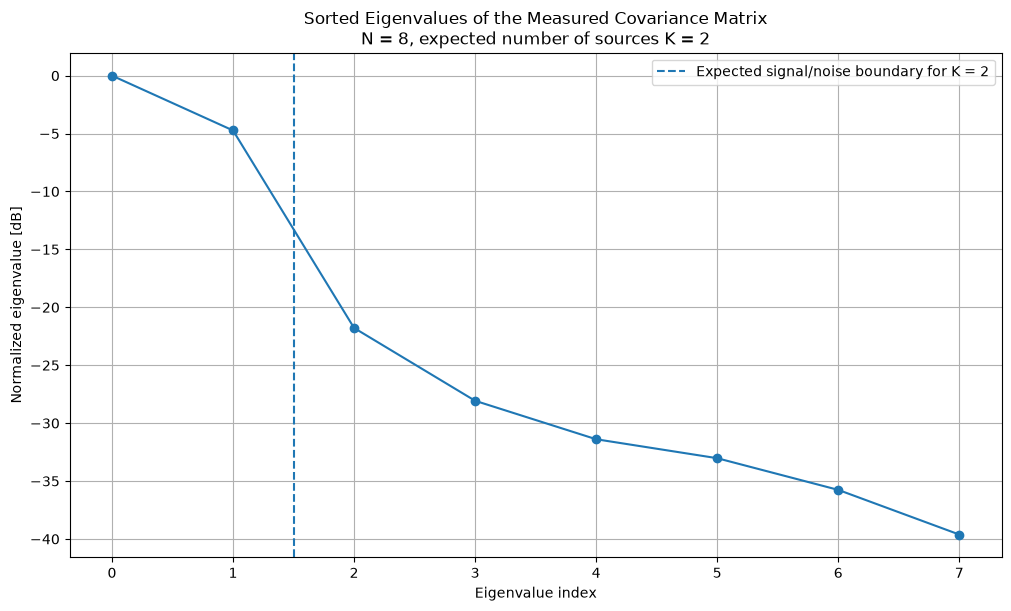

Loaded file           : ..\data\covariance_2_sources.npy
Covariance shape      : (8, 8)
Hermitian error       : 0.000e+00
Condition number      : 9.162e+03

Sorted eigenvalues:
  lambda[ 0] = 8.873714e+10 (   0.00 dB)
  lambda[ 1] = 2.983139e+10 (  -4.73 dB)
  lambda[ 2] = 5.884480e+08 ( -21.78 dB)
  lambda[ 3] = 1.383327e+08 ( -28.07 dB)
  lambda[ 4] = 6.440403e+07 ( -31.39 dB)
  lambda[ 5] = 4.418430e+07 ( -33.03 dB)
  lambda[ 6] = 2.353233e+07 ( -35.76 dB)
  lambda[ 7] = 9.685163e+06 ( -39.62 dB)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# Load covariance matrix
# ------------------------------------------------------------
data_path = Path("..") / "data" / "covariance_2_sources.npy"

if not data_path.exists():
    raise FileNotFoundError(
        f"Covariance matrix not found: {data_path.resolve()}"
    )

R = np.load(data_path)

if R.ndim != 2 or R.shape[0] != R.shape[1]:
    raise ValueError(
        f"Expected a square covariance matrix, got shape {R.shape}."
    )

N = R.shape[0]

# Known source count for this measurement
K = 2

# Enforce exact Hermitian symmetry against numerical roundoff
R = 0.5 * (R + R.conj().T)

# ------------------------------------------------------------
# Hermitian eigendecomposition
# ------------------------------------------------------------
eigenvalues, eigenvectors = np.linalg.eigh(R)

# np.linalg.eigh returns eigenvalues in ascending order
sort_idx = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[sort_idx]
eigenvectors = eigenvectors[:, sort_idx]

# Remove tiny negative values caused by numerical roundoff
eigenvalues = np.maximum(eigenvalues, 0.0)

# Normalize to the largest eigenvalue and convert to dB
eigenvalues_db = 10 * np.log10(
    np.maximum(eigenvalues, np.finfo(float).tiny)
    / eigenvalues[0]
)

# ------------------------------------------------------------
# Plot sorted eigenvalues
# ------------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(10, 6),
    constrained_layout=True
)

eigenvalue_idx = np.arange(N)

ax.plot(
    eigenvalue_idx,
    eigenvalues_db,
    marker="o"
)

ax.axvline(
    K - 0.5,
    linestyle="--",
    label=f"Expected signal/noise boundary for K = {K}"
)

ax.set_title(
    "Sorted Eigenvalues of the Measured Covariance Matrix\n"
    f"N = {N}, expected number of sources K = {K}"
)
ax.set_xlabel("Eigenvalue index")
ax.set_ylabel("Normalized eigenvalue [dB]")
ax.set_xticks(eigenvalue_idx)
ax.grid(True)
ax.legend()

plt.show()

# ------------------------------------------------------------
# Numerical summary
# ------------------------------------------------------------
print(f"Loaded file           : {data_path}")
print(f"Covariance shape      : {R.shape}")
print(f"Hermitian error       : "
      f"{np.linalg.norm(R - R.conj().T, ord='fro') / np.linalg.norm(R, ord='fro'):.3e}")
print(f"Condition number      : {np.linalg.cond(R):.3e}")

print("\nSorted eigenvalues:")
for idx, value in enumerate(eigenvalues):
    print(
        f"  lambda[{idx:2d}] = "
        f"{value:.6e} "
        f"({eigenvalues_db[idx]:7.2f} dB)"
    )

<a id="estimating-the-number-of-sources"></a>

## Estimating the Number of Sources

When the number of sources $K$ is unknown, it should not be determined simply by selecting eigenvalues above a fixed absolute threshold. The eigenvalue scale depends on source power, receiver noise power, the number of snapshots, array calibration, and covariance preprocessing.

A simple first estimate can be obtained by examining the sorted eigenvalue curve and locating a pronounced separation between two consecutive eigenvalues. The eigenvalue ratio can be defined as

$$
g_k
=
\frac{\lambda_k}{\lambda_{k+1}},
\qquad
k=0,\ldots,M-2.
$$

A large value of $g_k$ indicates a possible boundary between the signal and noise subspaces. The estimated number of sources is then

$$
\hat{K}
=
\underset{k}{\operatorname{arg\,max}}
\;
\frac{\lambda_k}{\lambda_{k+1}}
+
1.
$$

This **eigenvalue-gap method** is intuitive, but it may fail when:

- the sources have substantially different powers;
- one source has a low SNR;
- the sources are closely spaced;
- the number of snapshots is small;
- the sources are coherent;
- the noise is spatially colored;
- covariance snapshots contain different target combinations.

More systematic approaches use information-theoretic criteria such as Akaike's Information Criterion (AIC) and the Minimum Description Length (MDL) criterion. These methods evaluate several candidate values of $K$ and balance the data fit against model complexity.

In practice, source-number estimation can follow this sequence:

$$
\text{sorted eigenvalues}
\rightarrow
\text{eigenvalue-gap inspection}
\rightarrow
\text{AIC or MDL}
\rightarrow
\text{physical validation}.
$$

The final estimate should also be checked against radar-processing information such as detection clusters, expected target count, angular peak consistency, and stability across neighboring frames. Eigenvalue-based source counting should therefore be treated as a model-selection step rather than an infallible target detector.